# Phase 2 Fit Metrics

Inspect `window_sampling_fit` and `full_sequence_fit` artifacts emitted by `scripts/train_phase2_kl.py`. Training should run outside this notebook, ideally in `tmux`; this notebook only reads emitted artifacts.

In [1]:
from __future__ import annotations

import json
from collections import defaultdict
from pathlib import Path

# Leave FIT_ID empty to load the newest fit artifact containing metrics.jsonl.
FIT_ID = ""


def find_repo_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for path in (start, *start.parents):
        if (path / "pyproject.toml").exists() and (path / "src" / "picar_kl").exists():
            return path
    raise FileNotFoundError(f"Could not find repo root from {start}")


REPO_ROOT = find_repo_root()
ARTIFACT_ROOT = REPO_ROOT / "artifacts" / "models" / "phase2"


def newest_fit_dir(root: Path) -> Path:
    candidates = [path for path in root.iterdir() if (path / "metrics.jsonl").exists()]
    if not candidates:
        raise FileNotFoundError(f"No phase 2 fit artifacts under {root}")
    return max(candidates, key=lambda path: (path / "metrics.jsonl").stat().st_mtime)


fit_dir = ARTIFACT_ROOT / FIT_ID if FIT_ID else newest_fit_dir(ARTIFACT_ROOT)
metrics_path = fit_dir / "metrics.jsonl"
summary_path = fit_dir / "summary.json"
print(f"repo_root={REPO_ROOT}")
print(f"fit_dir={fit_dir}")
print(f"metrics_path={metrics_path}")


repo_root=/home/evan/Documents/notebooks/kl-projection
fit_dir=/home/evan/Documents/notebooks/kl-projection/artifacts/models/phase2/phase2-window-20260703T170537Z
metrics_path=/home/evan/Documents/notebooks/kl-projection/artifacts/models/phase2/phase2-window-20260703T170537Z/metrics.jsonl


In [2]:
rows = [json.loads(line) for line in metrics_path.read_text(encoding="utf-8").splitlines() if line.strip()]
summary = json.loads(summary_path.read_text(encoding="utf-8")) if summary_path.exists() else {}

def flatten_row(row: dict) -> dict:
    metrics = row.get("metrics", {})
    breakout = row.get("breakout", {})
    return {
        "row_type": row.get("row_type"),
        "epoch": row.get("epoch"),
        "batch_index": row.get("batch_index"),
        "split": breakout.get("split_name") or row.get("split_name"),
        "fit_mode": breakout.get("fit_mode"),
        "split_strategy": breakout.get("split_strategy"),
        "loss": row.get("loss"),
        "valid_steps": metrics.get("valid_steps"),
        "top1_accuracy": metrics.get("top1_accuracy"),
        "target_action_probability": metrics.get("target_action_probability"),
        "entropy": metrics.get("entropy"),
        "run_ids": ",".join(breakout.get("run_ids", [])),
    }

flat_rows = [flatten_row(row) for row in rows]
print(f"metric_rows={len(rows)}")
print(json.dumps({
    "run_id": summary.get("run_id"),
    "fit_mode": summary.get("fit_mode"),
    "final_loss": summary.get("training", {}).get("final_loss"),
    "dataset": summary.get("dataset", {}),
}, indent=2))


metric_rows=21600
{
  "run_id": "phase2-window-20260703T170537Z",
  "fit_mode": "window_sampling_fit",
  "final_loss": 2.304858526258613e-08,
  "dataset": {
    "allow_partial_cache": false,
    "candidate_window_count": 526,
    "context_steps": 8,
    "loaded_window_count": 526,
    "prediction_steps": 4,
    "selected_window_count": 526,
    "skipped_missing_cache_count": 0,
    "skipped_no_action_count": 2,
    "skipped_record_count": 2,
    "skipped_window_count": 0,
    "train_window_count": 421,
    "valid_target_steps": 336800,
    "validation_window_count": 105,
    "visual_token_shape": [
      24,
      2048
    ],
    "window_count": 526
  }
}


In [3]:
try:
    from IPython.display import display
except ImportError:
    display = None

def show_table(records, limit=20):
    records = records[:limit]
    if display is not None:
        try:
            import pandas as pd
            display(pd.DataFrame(records))
            return
        except ImportError:
            pass
    for record in records:
        print(record)

show_table(flat_rows[-20:])


,row_type,epoch,batch_index,split,fit_mode,split_strategy,loss,valid_steps,top1_accuracy,target_action_probability,entropy,run_ids
0,train_batch,199,88.0,train,window_sampling_fit,random_window,9.144141e-08,16,1.000000,1.000000,1.412566e-06,"04f639c9-478a-4cb2-ab4d-086813915793,d4cc1727-..."
1,train_batch,199,89.0,train,window_sampling_fit,random_window,9.466094e-08,16,1.000000,1.000000,1.382265e-06,04f639c9-478a-4cb2-ab4d-086813915793
2,train_batch,199,90.0,train,window_sampling_fit,random_window,1.455670e-07,16,1.000000,1.000000,2.598497e-06,"04f639c9-478a-4cb2-ab4d-086813915793,a1306251-..."
3,train_batch,199,91.0,train,window_sampling_fit,random_window,1.529107e-07,16,1.000000,1.000000,1.632222e-06,"04f639c9-478a-4cb2-ab4d-086813915793,375c751d-..."
4,train_batch,199,92.0,train,window_sampling_fit,random_window,1.105100e-07,16,1.000000,1.000000,2.387430e-06,04f639c9-478a-4cb2-ab4d-086813915793
5,train_batch,199,93.0,train,window_sampling_fit,random_window,1.082999e-07,16,1.000000,1.000000,2.398344e-06,"04f639c9-478a-4cb2-ab4d-086813915793,a1306251-..."
6,train_batch,199,94.0,train,window_sampling_fit,random_window,1.588449e-07,16,1.000000,1.000000,1.635127e-06,04f639c9-478a-4cb2-ab4d-086813915793
7,train_batch,199,95.0,train,window_sampling_fit,random_window,1.422628e-07,16,1.000000,1.000000,2.215980e-06,"04f639c9-478a-4cb2-ab4d-086813915793,d4cc1727-..."
8,train_batch,199,96.0,train,window_sampling_fit,random_window,7.352594e-08,16,1.000000,1.000000,1.189472e-06,"04f639c9-478a-4cb2-ab4d-086813915793,375c751d-..."
9,train_batch,199,97.0,train,window_sampling_fit,random_window,1.412381e-07,16,1.000000,1.000000,2.241028e-06,"04f639c9-478a-4cb2-ab4d-086813915793,d4cc1727-..."


In [4]:
eval_rows = [row for row in flat_rows if row["row_type"] == "eval_epoch"]
by_split = defaultdict(list)
for row in eval_rows:
    by_split[row["split"]].append(row)

print("Evaluation summary by split")
for split, split_rows in sorted(by_split.items()):
    latest = max(split_rows, key=lambda row: row["epoch"] if row["epoch"] is not None else -1)
    print({
        "split": split,
        "epochs": len(split_rows),
        "latest_epoch": latest["epoch"],
        "latest_loss": latest["loss"],
        "latest_top1_accuracy": latest["top1_accuracy"],
        "latest_target_action_probability": latest["target_action_probability"],
        "latest_entropy": latest["entropy"],
        "latest_valid_steps": latest["valid_steps"],
    })


Evaluation summary by split
{'split': 'train', 'epochs': 200, 'latest_epoch': 199, 'latest_loss': 1.4279322821020081e-07, 'latest_top1_accuracy': 1.0, 'latest_target_action_probability': 0.9999999079030369, 'latest_entropy': 2.098987160489225e-06, 'latest_valid_steps': 1684}
{'split': 'validation', 'epochs': 200, 'latest_epoch': 199, 'latest_loss': 0.03592932139746781, 'latest_top1_accuracy': 0.9976190476190476, 'latest_target_action_probability': 0.997611115810032, 'latest_entropy': 7.5189150552786e-05, 'latest_valid_steps': 420}


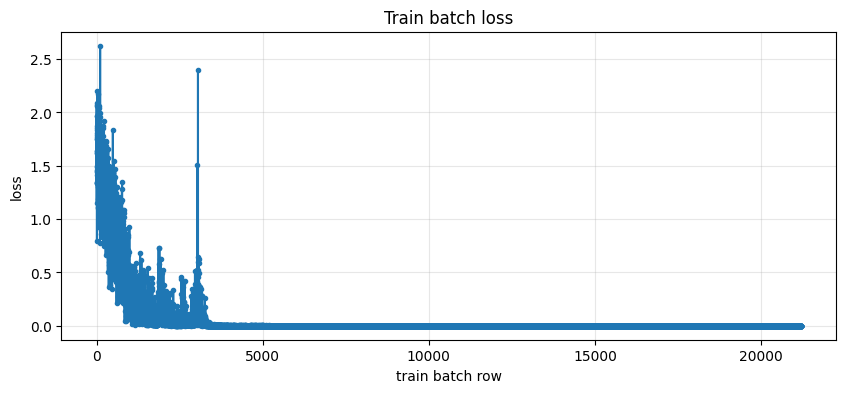

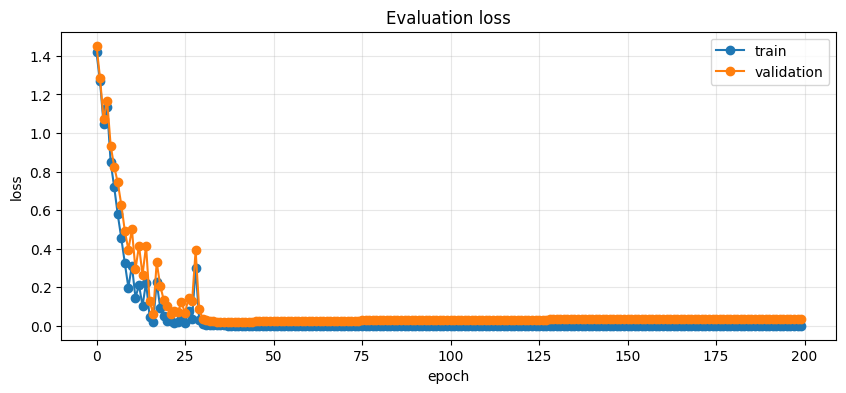

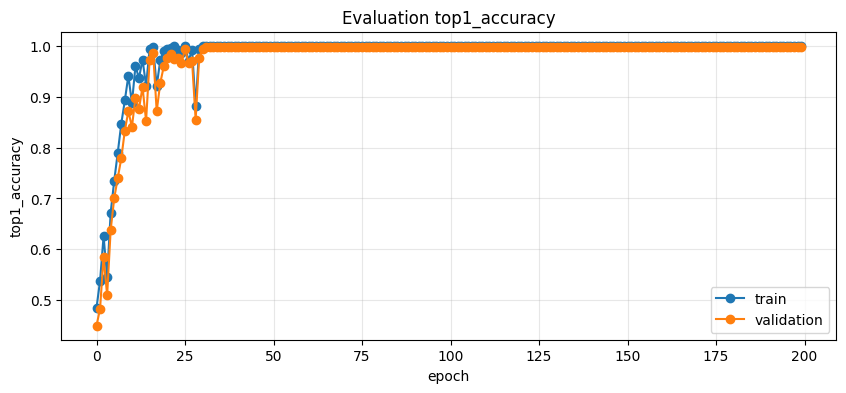

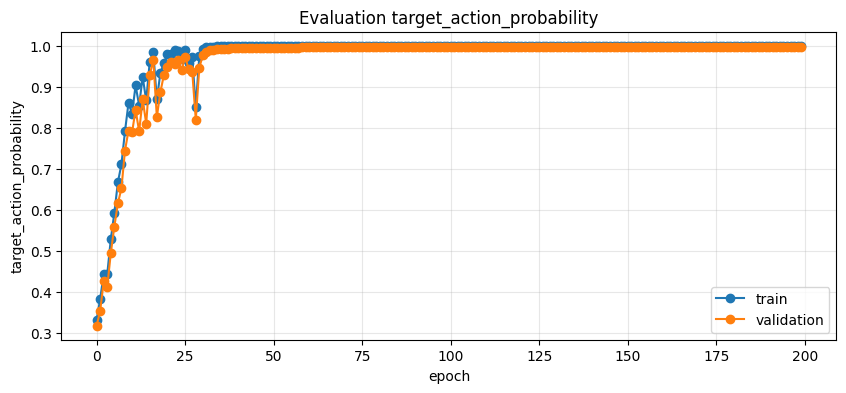

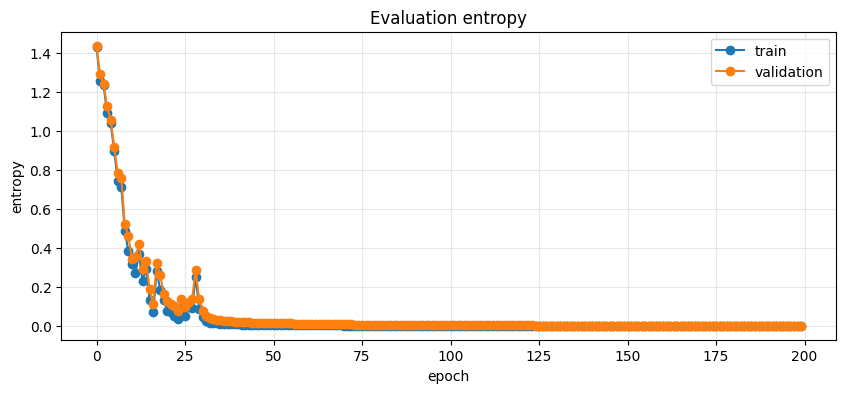

In [5]:
try:
    import matplotlib.pyplot as plt
except ImportError:
    plt = None

if plt is None:
    print("matplotlib is not installed; skipping plots. Tables above are still usable.")
else:
    train_rows = [row for row in flat_rows if row["row_type"] == "train_batch"]
    if train_rows:
        plt.figure(figsize=(10, 4))
        plt.plot([idx for idx, _ in enumerate(train_rows)], [row["loss"] for row in train_rows], marker=".")
        plt.title("Train batch loss")
        plt.xlabel("train batch row")
        plt.ylabel("loss")
        plt.grid(True, alpha=0.3)
        plt.show()

    for metric_name in ["loss", "top1_accuracy", "target_action_probability", "entropy"]:
        plt.figure(figsize=(10, 4))
        plotted = False
        for split, split_rows in sorted(by_split.items()):
            ys = [row[metric_name] for row in split_rows if row[metric_name] is not None]
            xs = [row["epoch"] for row in split_rows if row[metric_name] is not None]
            if ys:
                plt.plot(xs, ys, marker="o", label=split)
                plotted = True
        if plotted:
            plt.title(f"Evaluation {metric_name}")
            plt.xlabel("epoch")
            plt.ylabel(metric_name)
            plt.grid(True, alpha=0.3)
            plt.legend()
            plt.show()
        else:
            plt.close()


Latest eval split=validation epoch=199


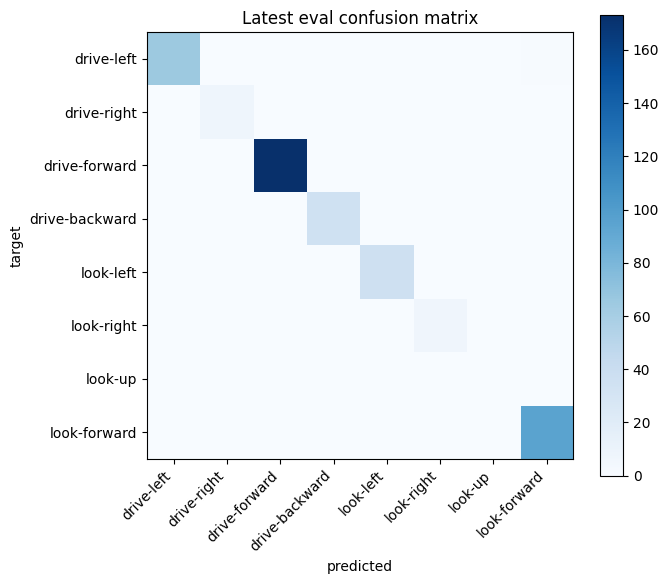

In [6]:
latest_eval = rows[-1] if rows else None
for row in reversed(rows):
    if row.get("row_type") == "eval_epoch":
        latest_eval = row
        break

if latest_eval is None:
    print("No eval rows found.")
else:
    metrics = latest_eval.get("metrics", {})
    matrix = metrics.get("confusion_matrix")
    names = metrics.get("action_names") or []
    print(f"Latest eval split={latest_eval.get("breakout", {}).get("split_name")} epoch={latest_eval.get("epoch")}")
    if plt is not None and matrix:
        plt.figure(figsize=(7, 6))
        plt.imshow(matrix, cmap="Blues")
        plt.title("Latest eval confusion matrix")
        plt.xlabel("predicted")
        plt.ylabel("target")
        plt.xticks(range(len(names)), names, rotation=45, ha="right")
        plt.yticks(range(len(names)), names)
        plt.colorbar()
        plt.tight_layout()
        plt.show()
    else:
        print(matrix)
